In [1]:
import source.helpers
import biolib
from pathlib import Path
import pandas as pd

from source import analysis, data, predict, regions
from source import path_method as pm

C:\Users\domin\anaconda3\envs\GLUT\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
C:\Users\domin\Desktop\GLUT\source\path_method.py:27: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(polyphen2_file, sep='\s+', names=columns, comment='#', na_values='nan')


In [2]:
# some libraries that might be neeeded
#pip install pymissense
#pip3 install --upgrade pybiolib 
#pip install gunicorn

In [3]:
grouped = True
if grouped:
    proteins = {
    'GLUT1':'P11166',
    'GLUT2':'P11168',
    'GLUT3':'P11169',
    'GLUT4':'P14672',
    'GLUT14':'Q8TDB8',#group 1
    'GLUT5':'P22732',
    'GLUT7':'Q6PXP3',
    'GLUT9':'Q9NRM0',
    'GLUT11':'Q9BYW1',#group2
    'GLUT6':'Q9UGQ3',
    'GLUT8':'Q9NY64',
    'GLUT10':'O95528',
    'GLUT12':'Q8TD20',
    'GLUT13':'Q96QE2' #group3
}
else:
    proteins = {
    'GLUT1':'P11166',
    'GLUT2':'P11168',
    'GLUT3':'P11169',
    'GLUT4':'P14672',
    'GLUT5':'P22732',
    'GLUT6':'Q9UGQ3',
    'GLUT7':'Q6PXP3',
    'GLUT8':'Q9NY64',
    'GLUT9':'Q9NRM0',
    'GLUT10':'O95528',
    'GLUT11':'Q9BYW1',
    'GLUT12':'Q8TD20',
    'GLUT13':'Q96QE2',
    'GLUT14':'Q8TDB8' 
    }

## get data

In [4]:
RES_DIR = Path.cwd() / 'results'
DATA_DIR = Path.cwd() / 'data'

#if results and data direcotries not exists create them
Path.mkdir(RES_DIR, exist_ok=True)
Path.mkdir(DATA_DIR, exist_ok=True)

In [5]:
#import pdb and fasta files
PDB_DIR = DATA_DIR / 'pdb'
FAS_DIR = DATA_DIR / 'fasta'

Path.mkdir(PDB_DIR, exist_ok=True)
Path.mkdir(FAS_DIR, exist_ok=True)
for up_id in proteins.values():
    
    data.get_pdb(up_id, PDB_DIR / f'{up_id}.pdb')
    data.get_fasta(up_id,FAS_DIR / f'{up_id}.fasta')

## get predictions for proteins

In [6]:
alpha_missense_tsv = DATA_DIR / 'AlphaMissense_aa_substitutions.tsv'
data.get_alphamissense(alpha_missense_tsv)

AlphaMissense data already exists


In [7]:
# run pymissense for all proteins and generate csv of aminoacid pathogenicities

PYM_DIR = RES_DIR / 'pymissense'
Path.mkdir(PYM_DIR, exist_ok=True)

for up_id in proteins.values():
    pdb_file = PDB_DIR / f'{up_id}.pdb'
    
    print(f'running PyMissense for {up_id}')
    predict.pymissense(alpha_missense_tsv, pdb_file, up_id, PYM_DIR)

running PyMissense for P11166
AlphaMissense prediction for P11166 already exists
running PyMissense for P11168
AlphaMissense prediction for P11168 already exists
running PyMissense for P11169
AlphaMissense prediction for P11169 already exists
running PyMissense for P14672
AlphaMissense prediction for P14672 already exists
running PyMissense for Q8TDB8
AlphaMissense prediction for Q8TDB8 already exists
running PyMissense for P22732
AlphaMissense prediction for P22732 already exists
running PyMissense for Q6PXP3
AlphaMissense prediction for Q6PXP3 already exists
running PyMissense for Q9NRM0
AlphaMissense prediction for Q9NRM0 already exists
running PyMissense for Q9BYW1
AlphaMissense prediction for Q9BYW1 already exists
running PyMissense for Q9UGQ3
AlphaMissense prediction for Q9UGQ3 already exists
running PyMissense for Q9NY64
AlphaMissense prediction for Q9NY64 already exists
running PyMissense for O95528
AlphaMissense prediction for O95528 already exists
running PyMissense for Q8TD2

## get protein regions

In [8]:
reg_prefix = {'all':'all',
            'extracellular':'O',
            'membrane':'M',
            'intracellular':'I',
            'lining residues':'lr',
            'binding pocket':'bp',
            'lining residues outside pocket':'nobp_lr'}

### all

In [9]:
REG_DIR = RES_DIR / 'regions'
Path.mkdir(REG_DIR, exist_ok=True)

In [10]:
for up_id in proteins.values():
    regions.all_residues(pdb_file = DATA_DIR / f'pdb/{up_id}.pdb', out_file = REG_DIR/ f'{reg_prefix['all']}_{up_id}.csv')

### intracellular, extracellular and membrane regions

In [11]:
#get annotations of AA positions relative to the membrane using 
DTM_DIR = RES_DIR / 'deeptmhmm'
Path.mkdir(DTM_DIR, exist_ok=True)

deeptmhmm = biolib.load('DTU/DeepTMHMM')
for up_id in proteins.values():
    predict.deepTMHMM(deeptmhmm, FAS_DIR / f'{up_id}.fasta', up_id, DTM_DIR)

2025-08-31 12:44:48,618 | INFO : Loaded project DTU/DeepTMHMM:1.0.44
DeepTMHMM prediction for P11166 already exists
DeepTMHMM prediction for P11168 already exists
DeepTMHMM prediction for P11169 already exists
DeepTMHMM prediction for P14672 already exists
DeepTMHMM prediction for Q8TDB8 already exists
DeepTMHMM prediction for P22732 already exists
DeepTMHMM prediction for Q6PXP3 already exists
DeepTMHMM prediction for Q9NRM0 already exists
DeepTMHMM prediction for Q9BYW1 already exists
DeepTMHMM prediction for Q9UGQ3 already exists
DeepTMHMM prediction for Q9NY64 already exists
DeepTMHMM prediction for O95528 already exists
DeepTMHMM prediction for Q8TD20 already exists
DeepTMHMM prediction for Q96QE2 already exists


In [12]:
#processing of depptmhmm results
intracel = reg_prefix['extracellular']
extracel = reg_prefix['intracellular']
memb = reg_prefix['membrane']
for up_id in proteins.values():
    regions.membrane_residues(DTM_DIR / f'{up_id}.3line', REG_DIR, up_id, extracel, intracel, memb)

### binding pockets, lining residues and nonpocket binding residues

In [13]:
# The amino acid residues lining the pores of individual proteins were calculated using: https://mole.upol.cz/ -LINING RESIDUES
# The amino acid residues framing the protein binding site were calculated using: https://prankweb.cz/ - BINDING PLACE
# The results were transcribed into an .xlsx document. Saved here /GLUT project documentation/Binding places and lining residues/Excel files/
# After transcription, a third column was created, where only those amino acid residues that were not part of the binding site but framed the protein pore were transcribed. -BINDING PLACE-LINING RESIDUES

In [14]:
#this step is hard to automatize
#uses csv file from PrankWeb
for up_id in proteins.values():
    regions.binding_pockets(prankweb_csv = DATA_DIR / f'prankweb/{up_id}.csv', out_file = REG_DIR/ f'{reg_prefix['binding pocket']}_{up_id}.csv')

In [15]:
##unziper na mole online
for glut in proteins.keys():
    file_path = DATA_DIR / f'moleonline/{glut}.zip'
    output = DATA_DIR / f'moleonline/{proteins[glut]}.json'
    source.helpers.mole_zip2json(file_path, output)

In [16]:
#lining residues
#from manually obrained JSON files from mole online
for up_id in proteins.values():
    regions.lining_residues(moleonline_json = DATA_DIR / f'moleonline/{up_id}.json', out_file = REG_DIR/ f'{reg_prefix['lining residues']}_{up_id}.csv')

In [17]:
#nonbinding pocket lining residues
for up_id in proteins.values():
    regions.nonbinding_pocket_lining_residues(bp_residues_csv = REG_DIR / f'{reg_prefix['binding pocket']}_{up_id}.csv', l_residues_csv = REG_DIR / f'{reg_prefix['lining residues']}_{up_id}.csv', out_file = REG_DIR / f'{reg_prefix['lining residues outside pocket']}_{up_id}.csv')

## assign pathogenicites

In [18]:
PAT_DIR = RES_DIR / 'pathogenicities'
AM_DIR = PAT_DIR / 'alphamissense'
PP_DIR = PAT_DIR / 'rhapsody'
SI_DIR = PAT_DIR / 'sift'

Path.mkdir(PAT_DIR, exist_ok=True)
Path.mkdir(AM_DIR, exist_ok=True)
Path.mkdir(PP_DIR, exist_ok=True)
Path.mkdir(SI_DIR, exist_ok=True)

In [19]:

for glut in proteins.keys():
    #process_file(input_folder / f'{glut}.txt', output_folder / f'all_{proteins[glut]}.csv')
    pm.polyphen2_residues(DATA_DIR / f'rhapsody/{glut}.txt', PP_DIR / f'all_{proteins[glut]}.csv')
# This can handle just one protein in a row, need to be repeated 14 times for each protein.

In [20]:
for glut in proteins.keys():
    pm.sift_residues(DATA_DIR / f'sift/SIFT_{glut}.txt', SI_DIR / f'all_{proteins[glut]}.csv')         

In [21]:
for up_id in proteins.values():
    am_patho_csv = AM_DIR / f'{reg_prefix['all']}_{up_id}.csv'
    pp_patho_csv = PP_DIR / f'{reg_prefix['all']}_{up_id}.csv'
    si_patho_csv = SI_DIR / f'{reg_prefix['all']}_{up_id}.csv'
    #create file for all
    pm.alphamissense_residues(RES_DIR / f'pymissense/{up_id}-edit.pdb', am_patho_csv)
    #create file for rest
    for reg in list(reg_prefix.keys())[1:]:
        analysis.assign_pathogenicity(am_patho_csv, region_csv = REG_DIR / f'{reg_prefix[reg]}_{up_id}.csv',out_file = AM_DIR / f'{reg_prefix[reg]}_{up_id}.csv')
        analysis.assign_pathogenicity(pp_patho_csv, region_csv = REG_DIR / f'{reg_prefix[reg]}_{up_id}.csv',out_file = PP_DIR / f'{reg_prefix[reg]}_{up_id}.csv')
        analysis.assign_pathogenicity(si_patho_csv, region_csv = REG_DIR / f'{reg_prefix[reg]}_{up_id}.csv',out_file = SI_DIR / f'{reg_prefix[reg]}_{up_id}.csv')

## average pathogenicities


In [22]:
for prefix in reg_prefix.values():
    analysis.average_pathogenicity(patho_dir = AM_DIR, region_prefix = prefix, up_id_list = proteins.values(), out_file = AM_DIR / f'{prefix}_average_patho.csv')
    analysis.average_pathogenicity(patho_dir = PP_DIR, region_prefix = prefix, up_id_list = proteins.values(), out_file = PP_DIR / f'{prefix}_average_patho.csv')
    analysis.average_pathogenicity(patho_dir = SI_DIR, region_prefix = prefix, up_id_list = proteins.values(), out_file = SI_DIR / f'{prefix}_average_patho.csv')


## united pathogenicites

In [23]:
if False:
    united_df = pd.read_csv(AM_DIR / f'{reg_prefix['all']}_average_patho.csv')
    united_df.columns = ['identifier', 'all']
    for reg in list(reg_prefix.keys())[1:]:
        pathogenicities = []
        df = pd.read_csv(AM_DIR / f'{reg_prefix[reg]}_average_patho.csv')
        for index, row in united_df.iterrows():
            identifier = row['identifier']
            pat = df[df.iloc[:,0]==identifier]['average_pathogenicity']
            pathogenicities.append(pat.iloc[0])
        united_df.loc[:, reg] = pathogenicities

In [24]:
for directory in [AM_DIR, PP_DIR, SI_DIR]:
    files = []
    for prefix in reg_prefix.values():
        files.append(directory / f'{prefix}_average_patho.csv')
    columns = ['identifier']+list(reg_prefix.keys())
    df = source.helpers.unite_csvs(files, directory / 'united_averages.csv', id_col = 1, colnames = columns, return_df = True)
df

,identifier,all,extracellular,membrane,intracellular,lining residues,binding pocket,lining residues outside pocket
0,P11166,0.193134,0.223739,0.162297,0.248812,0.139574,0.132947,0.149187
1,P11168,0.190770,0.205789,0.157747,0.254872,0.137654,0.124789,0.203158
2,P11169,0.187285,0.211825,0.158358,0.241453,0.137346,0.140153,0.151842
3,P14672,0.188431,0.219314,0.157697,0.238310,0.140366,0.131292,0.155211
4,Q8TDB8,0.184296,0.189713,0.160340,0.247722,0.142449,0.133021,0.167237
5,P22732,0.184984,0.208374,0.163456,0.212576,0.171410,0.147484,0.191316
6,Q6PXP3,0.188238,0.205503,0.163753,0.223313,0.144147,0.136818,0.149368
7,Q9NRM0,0.178921,0.176797,0.164819,0.238503,0.158396,0.148030,0.145263
8,Q9BYW1,0.189771,0.199838,0.170762,0.246212,0.175033,0.162196,0.205368
9,Q9UGQ3,0.183813,0.175523,0.158998,0.272575,0.152211,0.145602,0.143437


In [25]:
#rename to GLUT names
for directory in [AM_DIR, PP_DIR, SI_DIR]:
    for glut_id in proteins.keys():
        united_df = pd.read_csv(directory / 'united_averages.csv')
        i = united_df[united_df['identifier']==proteins[glut_id]].index
        united_df.at[i.values[0], 'identifier'] = glut_id
        united_df.to_csv(directory / 'united_averages.csv', index=False)

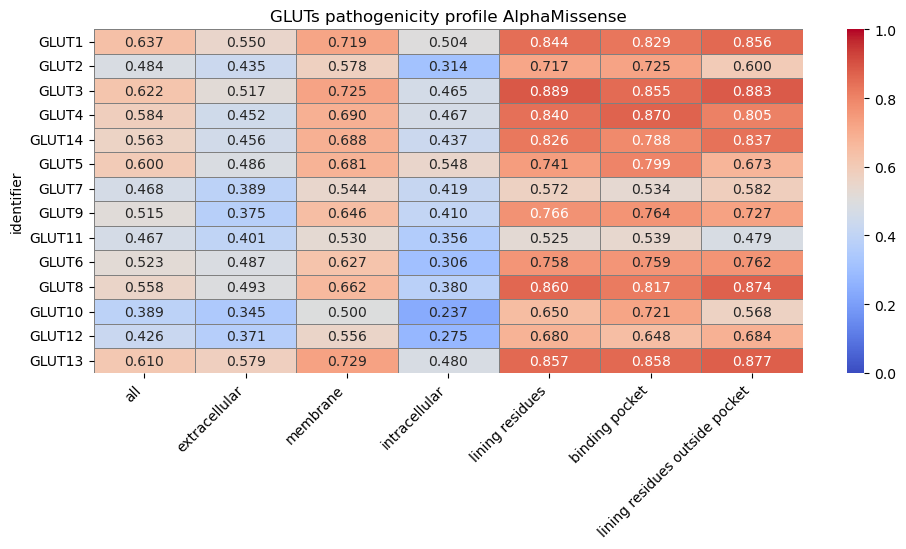

In [26]:
#create heatmaps
#alphamissense


analysis.crate_heatmap(AM_DIR / 'united_averages.csv', 'AlphaMissense', RES_DIR / 'AlphaMissense_pathogenicity_heatmap.png')

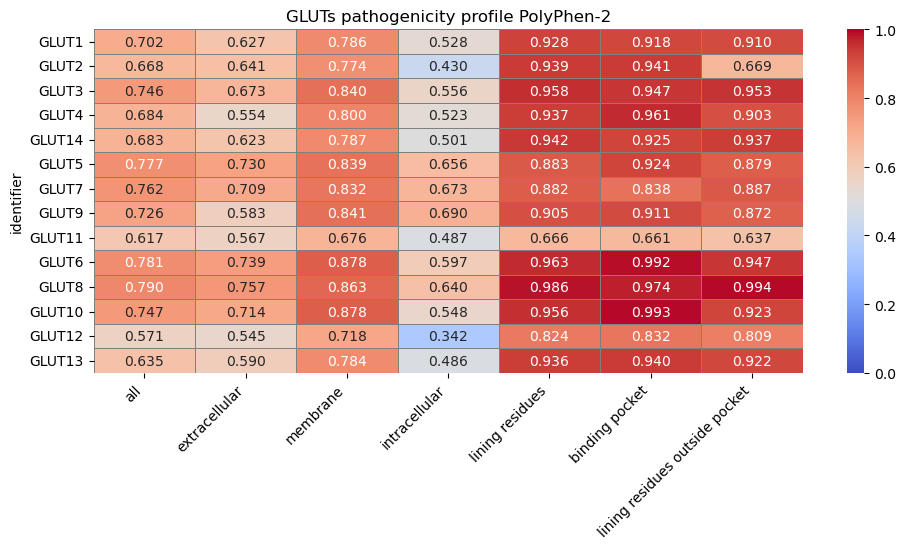

In [27]:
#create heatmaps
#polyphen-2


analysis.crate_heatmap(PP_DIR / 'united_averages.csv', 'PolyPhen-2', RES_DIR / 'PolyPhen-2_pathogenicity_heatmap.png')

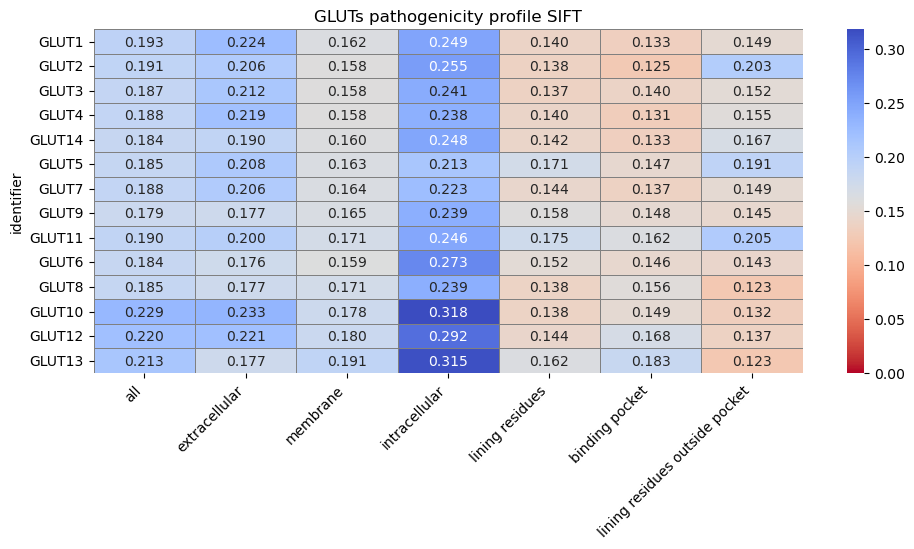

In [28]:
#create heatmaps
#sift

analysis.crate_heatmap(SI_DIR / 'united_averages.csv', 'SIFT', RES_DIR / 'SIFT_pathogenicity_heatmap.png', inverse_color = True)